<!-- import important libraries -->

In [48]:
print("rgvtg")

rgvtg


In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import seaborn as sns

<!-- import csv file -->

In [5]:
import pandas as pd

df = pd.read_csv("raw_data.csv", encoding="latin1")

print(df.head())

       Type  Days for shipping (real)  Days for shipment (scheduled)  \
0     DEBIT                         3                              4   
1  TRANSFER                         5                              4   
2      CASH                         4                              4   
3     DEBIT                         3                              4   
4   PAYMENT                         2                              4   

   Benefit per order  Sales per customer   Delivery Status  \
0          91.250000          314.640015  Advance shipping   
1        -249.089996          311.359985     Late delivery   
2        -247.779999          309.720001  Shipping on time   
3          22.860001          304.809998  Advance shipping   
4         134.210007          298.250000  Advance shipping   

   Late_delivery_risk  Category Id   Category Name Customer City  ...  \
0                   0           73  Sporting Goods        Caguas  ...   
1                   1           73  Sporting Goo

In [6]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


<!-- for theme  -->

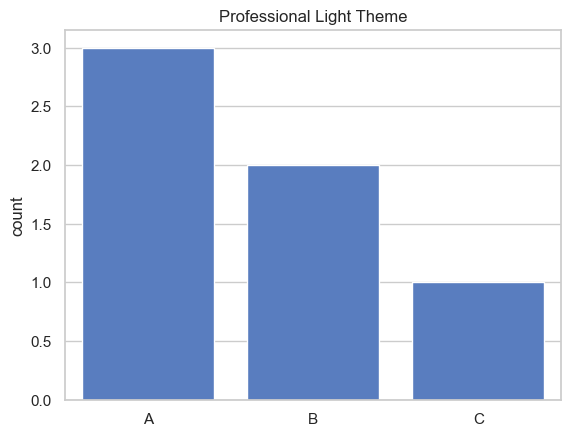

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", palette="muted")

data = ["A","B","C","A","B","A"]
sns.countplot(x=data)

plt.title("Professional Light Theme")
plt.show()

In [8]:
print(len(df))

180519


<!-- Expoloratory Data Analysis-->

In [9]:
# Overview
print('rows, cols:', df.shape)

print('\ncolumns:')
print(df.columns.tolist())

print('\nNum duplicates:', df.duplicated().sum())

print('\nMissing values (top 20):')
print(df.isna().sum().sort_values(ascending=False).head(20))

rows, cols: (180519, 53)

columns:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Produc

<!-- remove the not required columns -->

In [10]:
columns_to_drop = ['Product Description','Product Image','Customer Email','Customer Password','Customer Fname','Customer Lname','Customer Street','Customer Zipcode','Order Zipcode','Longitude','Latitude','Order Item Cardprod Id','Order Item Id','Order Item Discount','Order Item Discount Rate','Order Item Product Price','Order Item Quantity','Order Item Total','Category Id','Department Id','Order Id','Order Customer Id','Customer Id','Product Card Id','Product Category Id','Benefit per order','Product Status','Customer City','Order City','Order Country','Order State','Customer State','Market']

In [11]:
df.head(5)

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [12]:
df =df.drop(columns=columns_to_drop)

In [13]:
df.head(5)

,Type,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer Country,Customer Segment,Department Name,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Order Region,Order Status,Product Name,Product Price,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,314.640015,Advance shipping,0,Sporting Goods,Puerto Rico,Consumer,Fitness,1/31/2018 22:56,0.29,327.75,91.250000,Southeast Asia,COMPLETE,Smart watch,327.75,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,311.359985,Late delivery,1,Sporting Goods,Puerto Rico,Consumer,Fitness,1/13/2018 12:27,-0.80,327.75,-249.089996,South Asia,PENDING,Smart watch,327.75,1/18/2018 12:27,Standard Class
2,CASH,4,4,309.720001,Shipping on time,0,Sporting Goods,EE. UU.,Consumer,Fitness,1/13/2018 12:06,-0.80,327.75,-247.779999,South Asia,CLOSED,Smart watch,327.75,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,304.809998,Advance shipping,0,Sporting Goods,EE. UU.,Home Office,Fitness,1/13/2018 11:45,0.08,327.75,22.860001,Oceania,COMPLETE,Smart watch,327.75,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,298.250000,Advance shipping,0,Sporting Goods,Puerto Rico,Corporate,Fitness,1/13/2018 11:24,0.45,327.75,134.210007,Oceania,PENDING_PAYMENT,Smart watch,327.75,1/15/2018 11:24,Standard Class


<!-- remove the rows in which delivery are cacelled -->

<!-- see the datatypes  -->

In [14]:
print(df.dtypes)

Type                                 str
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Sales per customer               float64
Delivery Status                      str
Late_delivery_risk                 int64
Category Name                        str
Customer Country                     str
Customer Segment                     str
Department Name                      str
order date (DateOrders)              str
Order Item Profit Ratio          float64
Sales                            float64
Order Profit Per Order           float64
Order Region                         str
Order Status                         str
Product Name                         str
Product Price                    float64
shipping date (DateOrders)           str
Shipping Mode                        str
dtype: object


In [15]:

date_cols = [
    "order date (DateOrders)",
    "shipping date (DateOrders)"
]

df[date_cols] = df[date_cols].apply(pd.to_datetime, errors="coerce")

In [16]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

In [17]:
print(df.dtypes)

type                                        str
days_for_shipping_(real)                  int64
days_for_shipment_(scheduled)             int64
sales_per_customer                      float64
delivery_status                             str
late_delivery_risk                        int64
category_name                               str
customer_country                            str
customer_segment                            str
department_name                             str
order_date_(dateorders)          datetime64[us]
order_item_profit_ratio                 float64
sales                                   float64
order_profit_per_order                  float64
order_region                                str
order_status                                str
product_name                                str
product_price                           float64
shipping_date_(dateorders)       datetime64[us]
shipping_mode                               str
dtype: object


In [18]:

df = df[df["delivery_status"] != "Shipping canceled"]

In [19]:
print(df.shape)

(172765, 20)


<!-- value count for categorial column with  -->

In [20]:
for col in df.columns:
    if df[col].nunique() < 10:
        print(f"\n{col} value counts:")
        print(df[col].value_counts())


type value counts:
type
DEBIT       69295
TRANSFER    42129
PAYMENT     41725
CASH        19616
Name: count, dtype: int64

days_for_shipping_(real) value counts:
days_for_shipping_(real)
2    54205
6    27489
3    27478
4    27297
5    27003
0     4839
1     4454
Name: count, dtype: int64

days_for_shipment_(scheduled) value counts:
days_for_shipment_(scheduled)
4    103153
2     33806
1     26513
0      9293
Name: count, dtype: int64

delivery_status value counts:
delivery_status
Late delivery       98977
Advance shipping    41592
Shipping on time    32196
Name: count, dtype: int64

late_delivery_risk value counts:
late_delivery_risk
1    98977
0    73788
Name: count, dtype: int64

customer_country value counts:
customer_country
EE. UU.        106425
Puerto Rico     66340
Name: count, dtype: int64

customer_segment value counts:
customer_segment
Consumer       89420
Corporate      52528
Home Office    30817
Name: count, dtype: int64

order_status value counts:
order_status
COMPLETE  

<!-- find the payment failed which is processing  -->

In [21]:
import pandas as pd

# 1. Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# 2. Convert date columns
date_cols = ["order_date_(dateorders)", "shipping_date_(dateorders)"]
df[date_cols] = df[date_cols].apply(pd.to_datetime, errors="coerce")

# 3. Calculate order processing time
df['order_processing_time'] = (
    df['shipping_date_(dateorders)'] - df['order_date_(dateorders)']
).dt.days

# 4. Calculate delay
df['delay'] = df['order_processing_time'] - df['days_for_shipment_(scheduled)']

# 5. Delayed flag
df['is_delayed'] = df['delay'] > 0

# 6. Extract time features
df['order_month'] = df['order_date_(dateorders)'].dt.month
df['order_day'] = df['order_date_(dateorders)'].dt.day_name()
df['order_hour'] = df['order_date_(dateorders)'].dt.hour

# 7. Summary
print(df.describe())

       days_for_shipping_(real)  days_for_shipment_(scheduled)  \
count             172765.000000                  172765.000000   
mean                   3.498596                       2.933100   
min                    0.000000                       0.000000   
25%                    2.000000                       2.000000   
50%                    3.000000                       4.000000   
75%                    5.000000                       4.000000   
max                    6.000000                       4.000000   
std                    1.623446                       1.373405   

       sales_per_customer  late_delivery_risk     order_date_(dateorders)  \
count       172765.000000       172765.000000                      172765   
mean           183.165948            0.572900  2016-06-12 15:25:39.457991   
min              7.490000            0.000000         2015-01-01 00:00:00   
25%            104.379997            0.000000         2015-09-21 18:01:00   
50%            163.9

In [22]:
df['is_delayed'].value_counts()

is_delayed
True     94523
False    78242
Name: count, dtype: int64

In [23]:
print(df.dtypes)

type                                        str
days_for_shipping_(real)                  int64
days_for_shipment_(scheduled)             int64
sales_per_customer                      float64
delivery_status                             str
late_delivery_risk                        int64
category_name                               str
customer_country                            str
customer_segment                            str
department_name                             str
order_date_(dateorders)          datetime64[us]
order_item_profit_ratio                 float64
sales                                   float64
order_profit_per_order                  float64
order_region                                str
order_status                                str
product_name                                str
product_price                           float64
shipping_date_(dateorders)       datetime64[us]
shipping_mode                               str
order_processing_time                   

<!-- find the profit and the loss -->

In [24]:
# Profitability Flag based on Order Profit Per Order
df['Profitability Flag'] = np.where(
    df['order_profit_per_order'] > 0,
    'Profit',
    np.where(df['order_profit_per_order'] < 0, 'Loss', 'Break-even')
)

df['Profitability Flag'].value_counts()



Profitability Flag
Profit        139354
Loss           32295
Break-even      1116
Name: count, dtype: int64

<!-- visualization -->

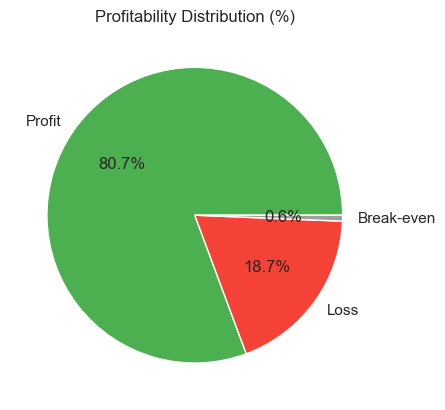

In [25]:
accent_color = "#4CAF50"
danger_color = "#F44336"
secondary_color = "#9E9E9E"

profit_counts = df['Profitability Flag'].value_counts(normalize=True) * 100

profit_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=[accent_color, danger_color, secondary_color]
)

plt.ylabel('')
plt.title('Profitability Distribution (%)')
plt.show()

<!-- creating the KPIs like  -->

In [26]:
total_orders = len(df)

late_deliveries = df['is_delayed'].sum()

late_deliveries_pct = (late_deliveries / total_orders) * 100
ontime_deliveries_pct = 100 - late_deliveries_pct

<!-- cross check if the missing values are avalable or not  -->

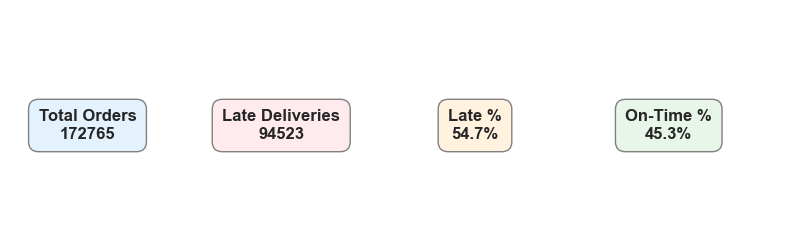

In [27]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')

cards = [
    f"Total Orders\n{total_orders}",
    f"Late Deliveries\n{late_deliveries}",
    f"Late %\n{late_deliveries_pct:.1f}%",
    f"On-Time %\n{ontime_deliveries_pct:.1f}%"
]

colors = ["#E3F2FD", "#FFEBEE", "#FFF3E0", "#E8F5E9"]  # light blue, red, orange, green

x_positions = [0.1, 0.35, 0.6, 0.85]

for text, x, color in zip(cards, x_positions, colors):
    ax.text(
        x, 0.5, text,
        ha='center', va='center',
        fontsize=12, weight='bold',
        bbox=dict(boxstyle="round,pad=0.6",
                  facecolor=color, edgecolor="gray")
    )

plt.show()

<!-- KPI for total profit,profit at the risk,delay average time ,average order profit -->

In [ ]:
# total profit
total_profit = df['order_profit_per_order'].sum()

# profit at risk (profit from delayed orders)
profit_at_risk = df[df['is_delayed'] == True]['order_profit_per_order'].sum()

# average delay time (only delayed orders)
avg_delay = df[df['is_delayed'] == True]['delay'].mean()

# average order profit 
avg_order_profit = df['order_profit_per_order'].mean()

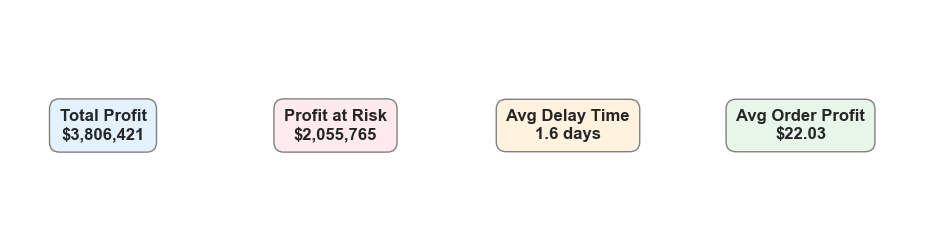

In [29]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 3))
ax.axis('off')

cards = [
    f"Total Profit\n${total_profit:,.0f}",
    f"Profit at Risk\n${profit_at_risk:,.0f}",
    f"Avg Delay Time\n{avg_delay:.1f} days",
    f"Avg Order Profit\n${avg_order_profit:.2f}"
]

colors = ["#E3F2FD", "#FFEBEE", "#FFF3E0", "#E8F5E9"]

x_positions = [0.1, 0.35, 0.6, 0.85]

for text, x, color in zip(cards, x_positions, colors):
    ax.text(
        x, 0.5, text,
        ha='center', va='center',
        fontsize=12, weight='bold',
        bbox=dict(boxstyle="round,pad=0.6",
                  facecolor=color, edgecolor="gray")
    )

plt.show()

<!-- bar charts on the percentage of orders vs delay days and total profit vs delay days -->

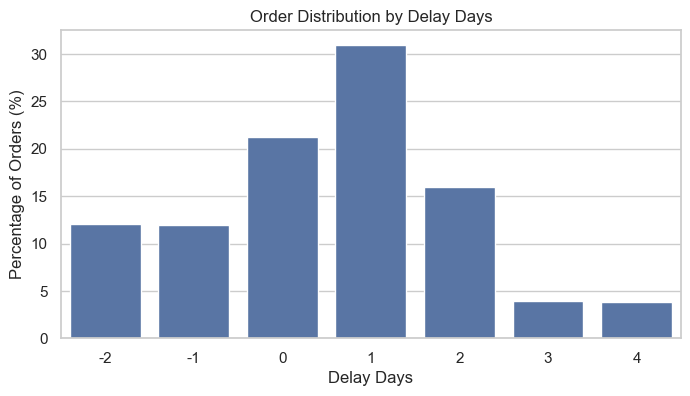

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# percentage of orders by delay days
delay_counts = df['delay'].value_counts(normalize=True).sort_index() * 100

sns.set_theme(style="whitegrid")

plt.figure(figsize=(8,4))
sns.barplot(x=delay_counts.index, y=delay_counts.values)

plt.xlabel("Delay Days")
plt.ylabel("Percentage of Orders (%)")
plt.title("Order Distribution by Delay Days")

plt.show()

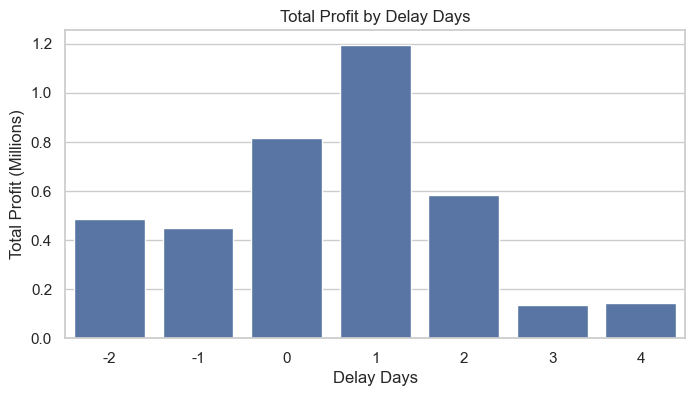

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# group data
profit_by_delay = df.groupby('delay')['order_profit_per_order'].sum().reset_index()

# convert to millions
profit_by_delay['profit_millions'] = profit_by_delay['order_profit_per_order'] / 1_000_000

# plot
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8,4))
sns.barplot(x='delay', y='profit_millions', data=profit_by_delay)

plt.xlabel("Delay Days")
plt.ylabel("Total Profit (Millions)")
plt.title("Total Profit by Delay Days")

plt.show()

<!-- craete the delay percentage by region -->

In [32]:
# calculate percentage of delayed orders per region
region_delay = (
    df.groupby('order_region')['is_delayed']
    .mean()
    .reset_index()
)

# convert to percentage
region_delay['delay_pct'] = region_delay['is_delayed'] * 100

# sort for better visualization
region_delay = region_delay.sort_values(by='delay_pct', ascending=True)

<!-- ordeer region vs delay % by order region -->

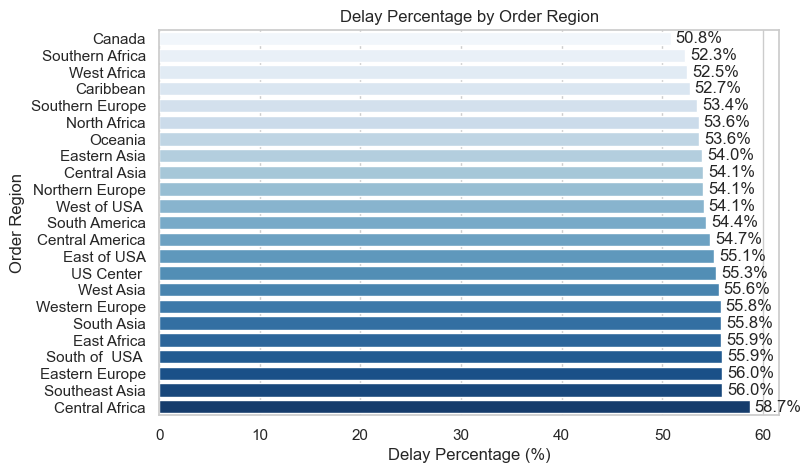

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# calculate percentage
region_delay = (
    df.groupby('order_region')['is_delayed']
    .mean()
    .reset_index()
)

region_delay['delay_pct'] = region_delay['is_delayed'] * 100
region_delay = region_delay.sort_values(by='delay_pct', ascending=True)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(8,5))
ax = sns.barplot(
    x='delay_pct',
    y='order_region',
    data=region_delay,
    palette='Blues'
)

# ✅ add percentage labels
for i, v in enumerate(region_delay['delay_pct']):
    ax.text(v + 0.5, i, f"{v:.1f}%", va='center')

plt.xlabel("Delay Percentage (%)")
plt.ylabel("Order Region")
plt.title("Delay Percentage by Order Region")

plt.show()

In [34]:
df.head(4)

,type,days_for_shipping_(real),days_for_shipment_(scheduled),sales_per_customer,delivery_status,late_delivery_risk,category_name,customer_country,customer_segment,department_name,...,product_price,shipping_date_(dateorders),shipping_mode,order_processing_time,delay,is_delayed,order_month,order_day,order_hour,Profitability Flag
0,DEBIT,3,4,314.640015,Advance shipping,0,Sporting Goods,Puerto Rico,Consumer,Fitness,...,327.75,2018-02-03 22:56:00,Standard Class,3,-1,False,1,Wednesday,22,Profit
1,TRANSFER,5,4,311.359985,Late delivery,1,Sporting Goods,Puerto Rico,Consumer,Fitness,...,327.75,2018-01-18 12:27:00,Standard Class,5,1,True,1,Saturday,12,Loss
2,CASH,4,4,309.720001,Shipping on time,0,Sporting Goods,EE. UU.,Consumer,Fitness,...,327.75,2018-01-17 12:06:00,Standard Class,4,0,False,1,Saturday,12,Loss
3,DEBIT,3,4,304.809998,Advance shipping,0,Sporting Goods,EE. UU.,Home Office,Fitness,...,327.75,2018-01-16 11:45:00,Standard Class,3,-1,False,1,Saturday,11,Profit


In [35]:
print(df.dtypes)

type                                        str
days_for_shipping_(real)                  int64
days_for_shipment_(scheduled)             int64
sales_per_customer                      float64
delivery_status                             str
late_delivery_risk                        int64
category_name                               str
customer_country                            str
customer_segment                            str
department_name                             str
order_date_(dateorders)          datetime64[us]
order_item_profit_ratio                 float64
sales                                   float64
order_profit_per_order                  float64
order_region                                str
order_status                                str
product_name                                str
product_price                           float64
shipping_date_(dateorders)       datetime64[us]
shipping_mode                               str
order_processing_time                   

<!-- customer segments vs delay % by customer segments  -->

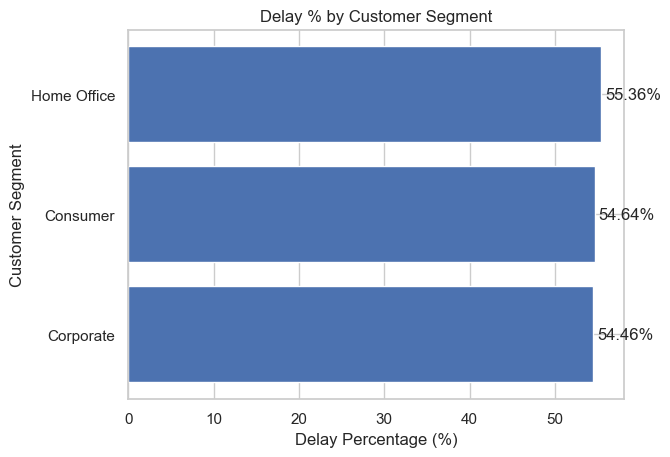

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert boolean to int
df["is_delayed"] = df["is_delayed"].astype(int)

# Group by customer segment
delay_df = df.groupby("customer_segment").agg(
    total_orders=("is_delayed", "count"),
    delayed_orders=("is_delayed", "sum")
)

# Calculate delay %
delay_df["delay_percentage"] = (delay_df["delayed_orders"] / delay_df["total_orders"]) * 100

# Sort
delay_df = delay_df.sort_values(by="delay_percentage", ascending=True)

# Plot
plt.figure()
bars = plt.barh(delay_df.index, delay_df["delay_percentage"])

# Add labels on bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2,
             f"{width:.2f}%", va='center')

# Labels
plt.xlabel("Delay Percentage (%)")
plt.ylabel("Customer Segment")
plt.title("Delay % by Customer Segment")

plt.show()

<!-- shipping mode vs delay % by shipping mode -->

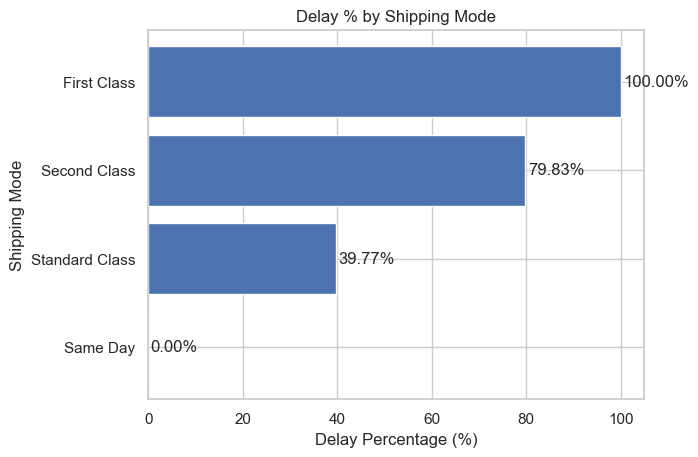

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert boolean to int
df["is_delayed"] = df["is_delayed"].astype(int)

# Group by shipping mode
delay_df = df.groupby("shipping_mode").agg(
    total_orders=("is_delayed", "count"),
    delayed_orders=("is_delayed", "sum")
)

# Calculate delay %
delay_df["delay_percentage"] = (delay_df["delayed_orders"] / delay_df["total_orders"]) * 100

# Sort
delay_df = delay_df.sort_values(by="delay_percentage", ascending=True)

# Plot
plt.figure()
bars = plt.barh(delay_df.index, delay_df["delay_percentage"])

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2,
             f"{width:.2f}%", va='center')

# Labels
plt.xlabel("Delay Percentage (%)")
plt.ylabel("Shipping Mode")
plt.title("Delay % by Shipping Mode")

plt.xlim(0, delay_df["delay_percentage"].max() + 5)

plt.show()

<!-- pament type vs delay % on type -->

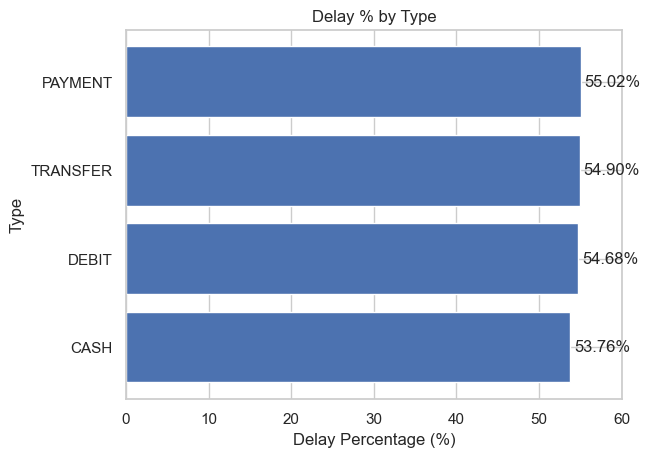

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert boolean to int
df["is_delayed"] = df["is_delayed"].astype(int)

# Group by type
delay_df = df.groupby("type").agg(
    total_orders=("is_delayed", "count"),
    delayed_orders=("is_delayed", "sum")
)

# Calculate delay %
delay_df["delay_percentage"] = (delay_df["delayed_orders"] / delay_df["total_orders"]) * 100

# Sort
delay_df = delay_df.sort_values(by="delay_percentage", ascending=True)

# Plot horizontal bar chart
plt.figure()
bars = plt.barh(delay_df.index, delay_df["delay_percentage"])

# Add labels on bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2,
             f"{width:.2f}%", va='center')

# Labels
plt.xlabel("Delay Percentage (%)")
plt.ylabel("Type")
plt.title("Delay % by Type")

# Add space for labels
plt.xlim(0, delay_df["delay_percentage"].max() + 5)

plt.show()

<!-- department vs delay % depatment  -->

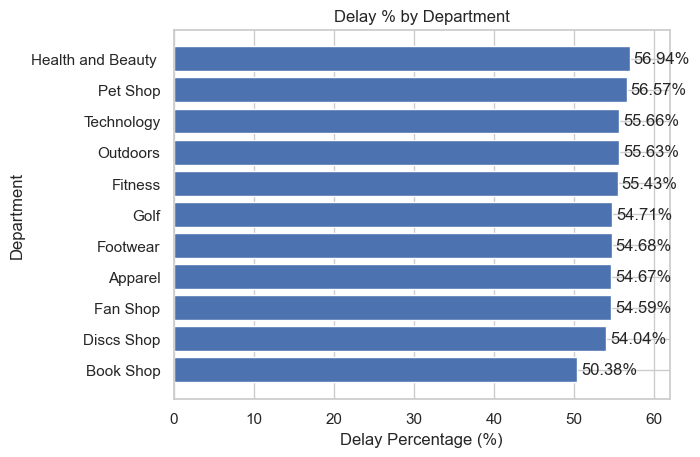

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert boolean to int
df["is_delayed"] = df["is_delayed"].astype(int)

# Group by department_name
delay_df = df.groupby("department_name").agg(
    total_orders=("is_delayed", "count"),
    delayed_orders=("is_delayed", "sum")
)

# Calculate delay %
delay_df["delay_percentage"] = (delay_df["delayed_orders"] / delay_df["total_orders"]) * 100

# Sort
delay_df = delay_df.sort_values(by="delay_percentage", ascending=True)

# Plot horizontal bar chart
plt.figure()
bars = plt.barh(delay_df.index, delay_df["delay_percentage"])

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2,
             f"{width:.2f}%", va='center')

# Labels
plt.xlabel("Delay Percentage (%)")
plt.ylabel("Department")
plt.title("Delay % by Department")

# Add space for labels
plt.xlim(0, delay_df["delay_percentage"].max() + 5)

plt.show()

<!-- order status vs delay % in order status -->

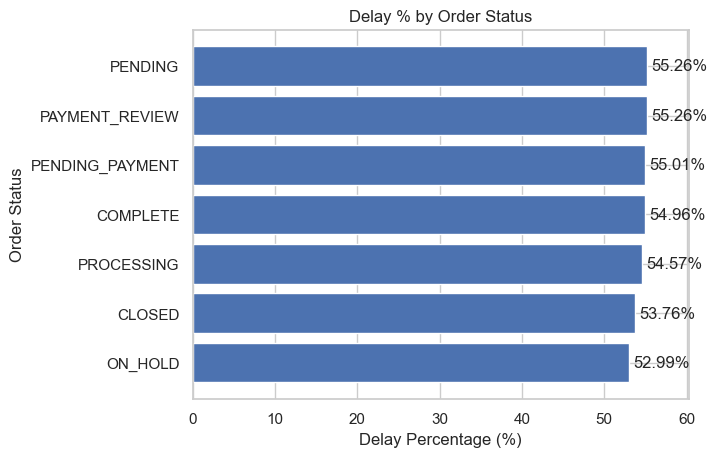

In [40]:
import matplotlib.pyplot as plt

# Convert boolean to int
df["is_delayed"] = df["is_delayed"].astype(int)

# Group by order_status
delay_df = df.groupby("order_status").agg(
    total_orders=("is_delayed", "count"),
    delayed_orders=("is_delayed", "sum")
)

# Calculate delay %
delay_df["delay_percentage"] = (delay_df["delayed_orders"] / delay_df["total_orders"]) * 100

# Sort descending (better for analysis)
delay_df = delay_df.sort_values(by="delay_percentage", ascending=False)

# Plot
plt.figure()
bars = plt.barh(delay_df.index, delay_df["delay_percentage"])

# Add labels on bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2,
             f"{width:.2f}%", va='center')

# Labels
plt.xlabel("Delay Percentage (%)")
plt.ylabel("Order Status")
plt.title("Delay % by Order Status")

# Invert y-axis so highest is on top
plt.gca().invert_yaxis()

# Add space for labels
plt.xlim(0, delay_df["delay_percentage"].max() + 5)

plt.show()

<!-- ROOT CAUSE ANALYSIS  -->

<!-- root analysis in east africa  -->

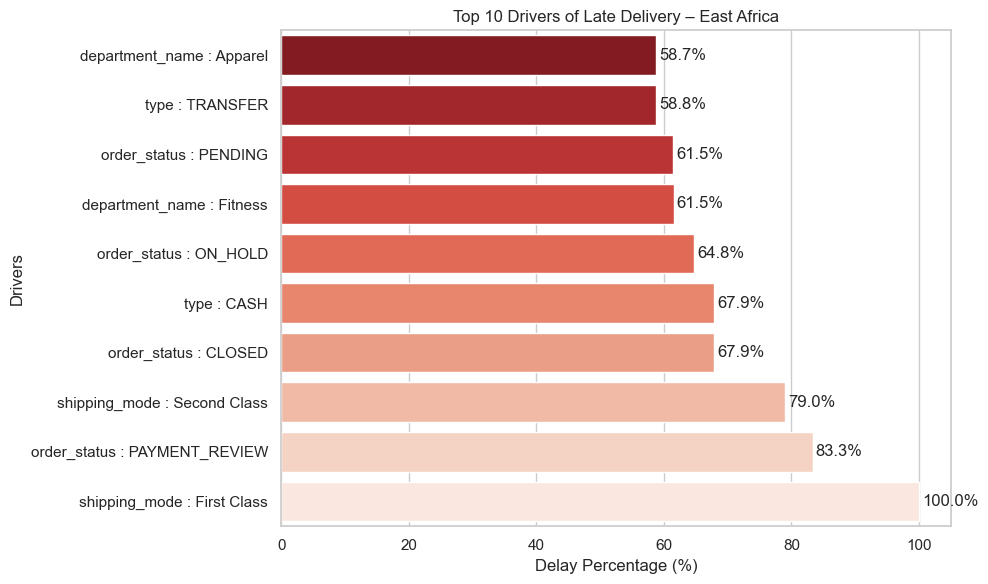

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def top_drivers_for_region(region):
    
    # Filter region
    df_region = df[df['order_region'] == region].copy()

    # Drivers to analyze
    drivers = ['shipping_mode', 'customer_segment', 'department_name', 'type', 'order_status']

    all_factors = []

    for factor in drivers:
        temp = (
            df_region.groupby(factor)
            .agg(
                total_orders=('is_delayed', 'count'),
                late_orders=('is_delayed', 'sum')
            )
            .reset_index()
        )

        # Calculate delay %
        temp['delay_pct'] = (temp['late_orders'] / temp['total_orders']) * 100
        
        # Add labels
        temp['Driver'] = factor
        temp['Factor_Level'] = factor + " : " + temp[factor].astype(str)

        all_factors.append(temp)

    # Combine all drivers
    final_df = pd.concat(all_factors, ignore_index=True)

    # Get top 10 drivers
    final_df = final_df.sort_values(by='delay_pct', ascending=False).head(10)

    # Sort for horizontal bar
    final_df = final_df.sort_values(by='delay_pct', ascending=True)

    return final_df


# 🔥 Run for East Africa
result = top_drivers_for_region("East Africa")

# Plot
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,6))

ax = sns.barplot(
    x="delay_pct",
    y="Factor_Level",
    data=result,
    palette="Reds_r"
)

# Add labels
for i, v in enumerate(result["delay_pct"]):
    ax.text(v + 0.5, i, f"{v:.1f}%", va='center')

plt.xlabel("Delay Percentage (%)")
plt.ylabel("Drivers")
plt.title("Top 10 Drivers of Late Delivery – East Africa")

plt.xlim(0, result["delay_pct"].max() + 5)

plt.tight_layout()
plt.show()

<!-- root analysis in Southeast Asia -->

In [42]:
result = top_drivers_for_region("Southeast Asia")

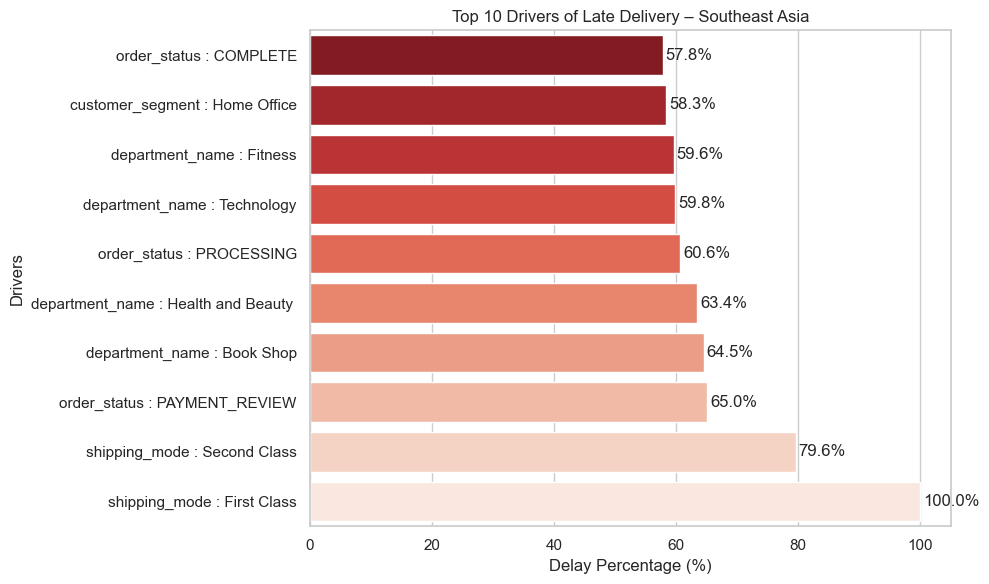

In [43]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,6))

ax = sns.barplot(
    x="delay_pct",
    y="Factor_Level",
    data=result,
    palette="Reds_r"
)

# Add labels
for i, v in enumerate(result["delay_pct"]):
    ax.text(v + 0.5, i, f"{v:.1f}%", va='center')

plt.xlabel("Delay Percentage (%)")
plt.ylabel("Drivers")
plt.title("Top 10 Drivers of Late Delivery – Southeast Asia")

plt.xlim(0, result["delay_pct"].max() + 5)

plt.tight_layout()
plt.show()

<!-- DATE BASED ANALYSIS -->

<!-- # Delay % by Month, Day of Week, Hour

# -------------------------------
# Delay by Month
# ------------------------------- -->

In [44]:

delay_by_month = (
    df.groupby('order_month')['is_delayed']
    .mean()
    .reset_index()
)

delay_by_month['delay_pct'] = delay_by_month['is_delayed'] * 100


# -------------------------------
# Delay by Day
# -------------------------------
delay_by_day = (
    df.groupby('order_day')['is_delayed']
    .mean()
    .reset_index()
)

delay_by_day['delay_pct'] = delay_by_day['is_delayed'] * 100


# -------------------------------
# Delay by Hour
# -------------------------------
delay_by_hour = (
    df.groupby('order_hour')['is_delayed']
    .mean()
    .reset_index()
)

delay_by_hour['delay_pct'] = delay_by_hour['is_delayed'] * 100

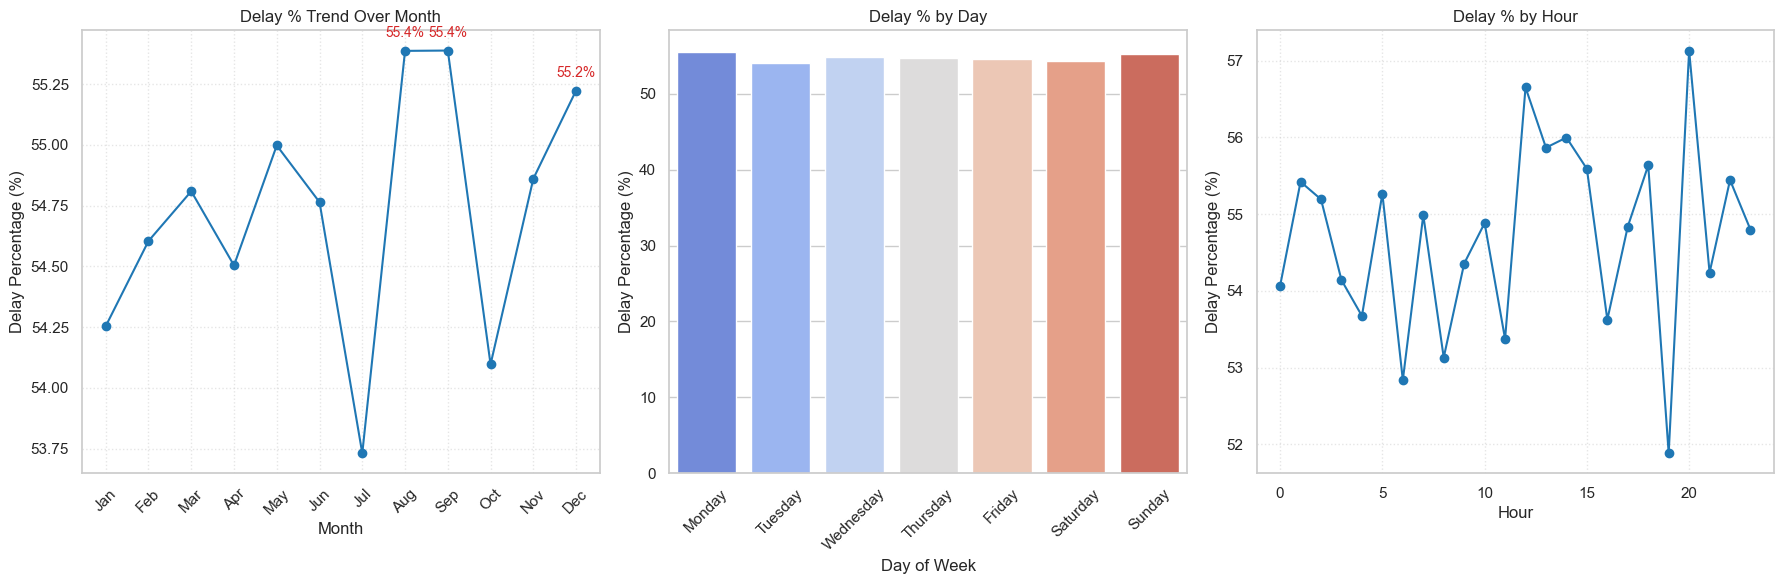

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# COLORS (you can customize)
# -------------------------------
primary_color = "#1f77b4"
danger_color = "#d62728"

sns.set_theme(style="whitegrid")

# -------------------------------
# DATA PREPARATION
# -------------------------------

# Delay by Month
delay_by_month = (
    df.groupby('order_month')['is_delayed']
    .mean()
    .reset_index()
)
delay_by_month['delay_pct'] = delay_by_month['is_delayed'] * 100


# Delay by Day
delay_by_day = (
    df.groupby('order_day')['is_delayed']
    .mean()
    .reset_index()
)
delay_by_day['delay_pct'] = delay_by_day['is_delayed'] * 100


# Delay by Hour
delay_by_hour = (
    df.groupby('order_hour')['is_delayed']
    .mean()
    .reset_index()
)
delay_by_hour['delay_pct'] = delay_by_hour['is_delayed'] * 100


# -------------------------------
# SORT DAYS PROPERLY
# -------------------------------
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

delay_by_day['order_day'] = pd.Categorical(
    delay_by_day['order_day'],
    categories=day_order,
    ordered=True
)

delay_by_day = delay_by_day.sort_values('order_day')


# -------------------------------
# CREATE SUBPLOTS
# -------------------------------
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))


# ===============================
# 1️⃣ Delay % by Month
# ===============================
ax1.plot(
    delay_by_month['order_month'],
    delay_by_month['delay_pct'],
    marker='o',
    color=primary_color
)

ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(
    ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'],
    rotation=45
)

ax1.set_xlabel("Month")
ax1.set_ylabel("Delay Percentage (%)")
ax1.set_title("Delay % Trend Over Month")
ax1.grid(True, linestyle=':', alpha=0.5)

# 🔥 Annotate top 3 months
top3_month = delay_by_month.nlargest(3, 'delay_pct')

for _, row in top3_month.iterrows():
    ax1.annotate(
        f"{row['delay_pct']:.1f}%",
        (row['order_month'], row['delay_pct']),
        textcoords="offset points",
        xytext=(0,10),
        ha='center',
        fontsize=10,
        color=danger_color
    )


# ===============================
# 2️⃣ Delay % by Day
# ===============================
sns.barplot(
    x='order_day',
    y='delay_pct',
    data=delay_by_day,
    palette='coolwarm',
    ax=ax2
)

ax2.set_xlabel("Day of Week")
ax2.set_ylabel("Delay Percentage (%)")
ax2.set_title("Delay % by Day")
ax2.tick_params(axis='x', rotation=45)


# ===============================
# 3️⃣ Delay % by Hour
# ===============================
ax3.plot(
    delay_by_hour['order_hour'],
    delay_by_hour['delay_pct'],
    marker='o',
    color=primary_color
)

ax3.set_xlabel("Hour")
ax3.set_ylabel("Delay Percentage (%)")
ax3.set_title("Delay % by Hour")
ax3.grid(True, linestyle=':', alpha=0.5)


# -------------------------------
# FINAL LAYOUT
# -------------------------------
plt.tight_layout()
plt.show()

In [46]:
print(df.dtypes)

type                                        str
days_for_shipping_(real)                  int64
days_for_shipment_(scheduled)             int64
sales_per_customer                      float64
delivery_status                             str
late_delivery_risk                        int64
category_name                               str
customer_country                            str
customer_segment                            str
department_name                             str
order_date_(dateorders)          datetime64[us]
order_item_profit_ratio                 float64
sales                                   float64
order_profit_per_order                  float64
order_region                                str
order_status                                str
product_name                                str
product_price                           float64
shipping_date_(dateorders)       datetime64[us]
shipping_mode                               str
order_processing_time                   

In [49]:
df['is_delayed'] = df['is_delayed'].astype(bool)
df['delay'] = df['delay'].astype(int)

In [50]:
df.to_csv("cleaned_data.csv", index=False)